In [236]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency
import itertools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import shap

c:\Users\danie\WebstormProjects\churn-investigation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [205]:
# skip column analysis since this is already in the data description
# check missing values
# minor data cleaning (remove columns, values, etc that are "not relevant" [customer satisfaction seems suspicious])
# check for outliers --> values are given in data description, however, investigate. given != always actual
# check for duplicates (based on customer ID - check whether this is unique or whether we have Q1 values and Q2 values in there)
# analyse the distribution of the target variable

# check correlation between features and target variable

# create a dataset -> create a train / val / test split, feature engineering, dropping irrelevant values
# normalizing the data, encoding, categorizing


# intuitively use XGBoost model / logistic regression to predict target variable
# evaluate using metrics such as top-k (precision@k, recall@k), precision, recall, AU-ROC PR-AUC / average precisio
# 


# mabye use top-k as pitch for the task 2
# use SHAP values to explain the model and find out which features are most important for the prediction of churn
# use the insights from the SHAP values to create a customer retention strategy, e.g. by identifying which customers are most likely to churn and targeting them with specific retention efforts

# explain how the model could be pushed to production, api that takes in user data and returns a prediction
# when should the model be run? every day, every week, etc. and how to integrate it into the existing system of the company


In [206]:
# read with every colum forced to lowercase to avoid issues with column names
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,CustomerSatisfactionScore,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,NaN,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,NaN,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,6.0,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),NaN,42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,1.0,70.70,151.65,Yes


In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   gender                     7043 non-null   str    
 2   SeniorCitizen              7043 non-null   int64  
 3   Partner                    7043 non-null   str    
 4   Dependents                 7043 non-null   str    
 5   tenure                     7043 non-null   int64  
 6   PhoneService               7043 non-null   str    
 7   MultipleLines              7043 non-null   str    
 8   InternetService            7043 non-null   str    
 9   OnlineSecurity             7043 non-null   str    
 10  OnlineBackup               7043 non-null   str    
 11  DeviceProtection           7043 non-null   str    
 12  TechSupport                7043 non-null   str    
 13  StreamingTV                7043 non-null   str    
 14  Str

In [160]:
# check for the length and whether there are duplicated values in the dataset
print("Number of rows in the dataset:", len(df))
print("Number of unique customers in the dataset:", df['customerID'].nunique())
print("We have no duplicated values, so this is a clean dataset when it comes to different customers")

Number of rows in the dataset: 7043
Number of unique customers in the dataset: 7043
We have no duplicated values, so this is a clean dataset when it comes to different customers


# Data analysis

In [161]:
df['SeniorCitizen'] = np.where(df['SeniorCitizen'] == 1, 'Yes', 'No')

In [199]:
def visualize_non_numerical_variable(df, columns):
    # create a subplot for each column in columns showing the distribution of the variable in percentage
    n = len(columns)
    nrows = math.ceil(n / 3)
    fig, axes = plt.subplots(nrows, 3, figsize=(12, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, column in zip(axes, columns):
        counts = df[column].value_counts(normalize=True) * 100
        colors = plt.cm.tab10(range(len(counts)))
        ax.bar(counts.index.astype(str), counts.values, color=colors)
        ax.set_xlabel(column.capitalize())
        ax.set_ylabel('Percentage (%)')
        ax.set_title(f'Distribution of {column.capitalize()}')
        ax.tick_params(axis='x', rotation=45)
        for i, v in enumerate(counts.values):
            ax.text(i, 0.8, f'{v:.1f}%', ha='center', fontsize=10)
        
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

def non_numerical_churn_distribution(df, columns, target='Churn'):
    """ 
        The goal is to visualize the churn rate next to the plots of the distribution, 
        i.e. a bar chart with the distribution of the variable that let's us answer:
        'These are the number of {column} customers of which X% who churned'
        The goal is an initial visualization of the distribution. 
        Each feature is shown independently, so we can see the distribution of the feature and the churn rate for each category of the feature.
    """
    n = len(columns)
    nrows = math.ceil(n / 3)
    fig, axes = plt.subplots(nrows, 3, figsize=(5 * 3, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, column in zip(axes, columns):
        # overall share of each category (bar height)
        category_share = df[column].value_counts(normalize=True) * 100

        # churn rate within each category (stacked split)
        churn_rate = df.groupby(column)[target].apply(lambda x: (x == 'Yes').mean() * 100)
        retain_rate = 100 - churn_rate

        categories = category_share.index.astype(str)
        x = range(len(categories))

        colors = plt.cm.tab10(range(len(categories)))
        ax.bar(x, retain_rate[category_share.index] / 100 * category_share.values,
               color=colors[0], label='Retained')
        ax.bar(x, churn_rate[category_share.index] / 100 * category_share.values,
               bottom=retain_rate[category_share.index] / 100 * category_share.values,
               color=colors[1], label='Churned')

        # annotate total bar height and churn % inside the red segment
        for i, (cat, share) in enumerate(zip(category_share.index, category_share.values)):
            retain_abs = retain_rate[cat] / 100 * share
            ax.text(i, 0.8, f'{share:.1f}% (wd)', ha='center', fontsize=10)
            ax.text(i, retain_abs + 0.8, f'{churn_rate[cat]:.1f}% (cd)',
                    ha='center', fontsize=10)

        ax.set_xticks(list(x))
        ax.set_xticklabels(categories, rotation=15, ha='right')
        ax.set_xlabel(column.capitalize())
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('% of Total Customers')
        ax.set_title(f'{column.capitalize()}')
        ax.legend(fontsize=10)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

def cramers_v(x, y):
    """
        Calculate the correlation via Cramer's V between two categorical variables
        (similar to pearson correlation, but for categorical variables)
        -- using chi squared to calculate the correlation between two categorical variables
    """
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0] # small chi2 value means that the two variables are independent, while a large chi2 value indicates that they are dependent
    n = confusion.sum().sum() # normalize the chi2 value by the total number of observations to get a value between 0 and 1
    phi2 = chi2 / n
    r, k = confusion.shape

    # apply bias correction (Bergsma)
    # reasoning: independent pairs land near 0 instead of a positive, it basically just corrects for the fact that the chi2 value is always positive, 
    # even for independent variables, and it also corrects for the fact that the chi2 value is larger for larger sample sizes
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


def categorical_association_matrix(df, columns):
    """
        Create a  the matrix of Cramer's V values for all combinations of categorical variables in the dataframe
    """
    m = pd.DataFrame(np.eye(len(columns)), index=columns, columns=columns)
    # just iterate over every cell block combo and fill in the cramber values that are cleansed to build the matrix
    for c1, c2 in itertools.combinations(columns, 2):
        v = cramers_v(df[c1], df[c2])
        m.loc[c1, c2] = m.loc[c2, c1] = v
    return m

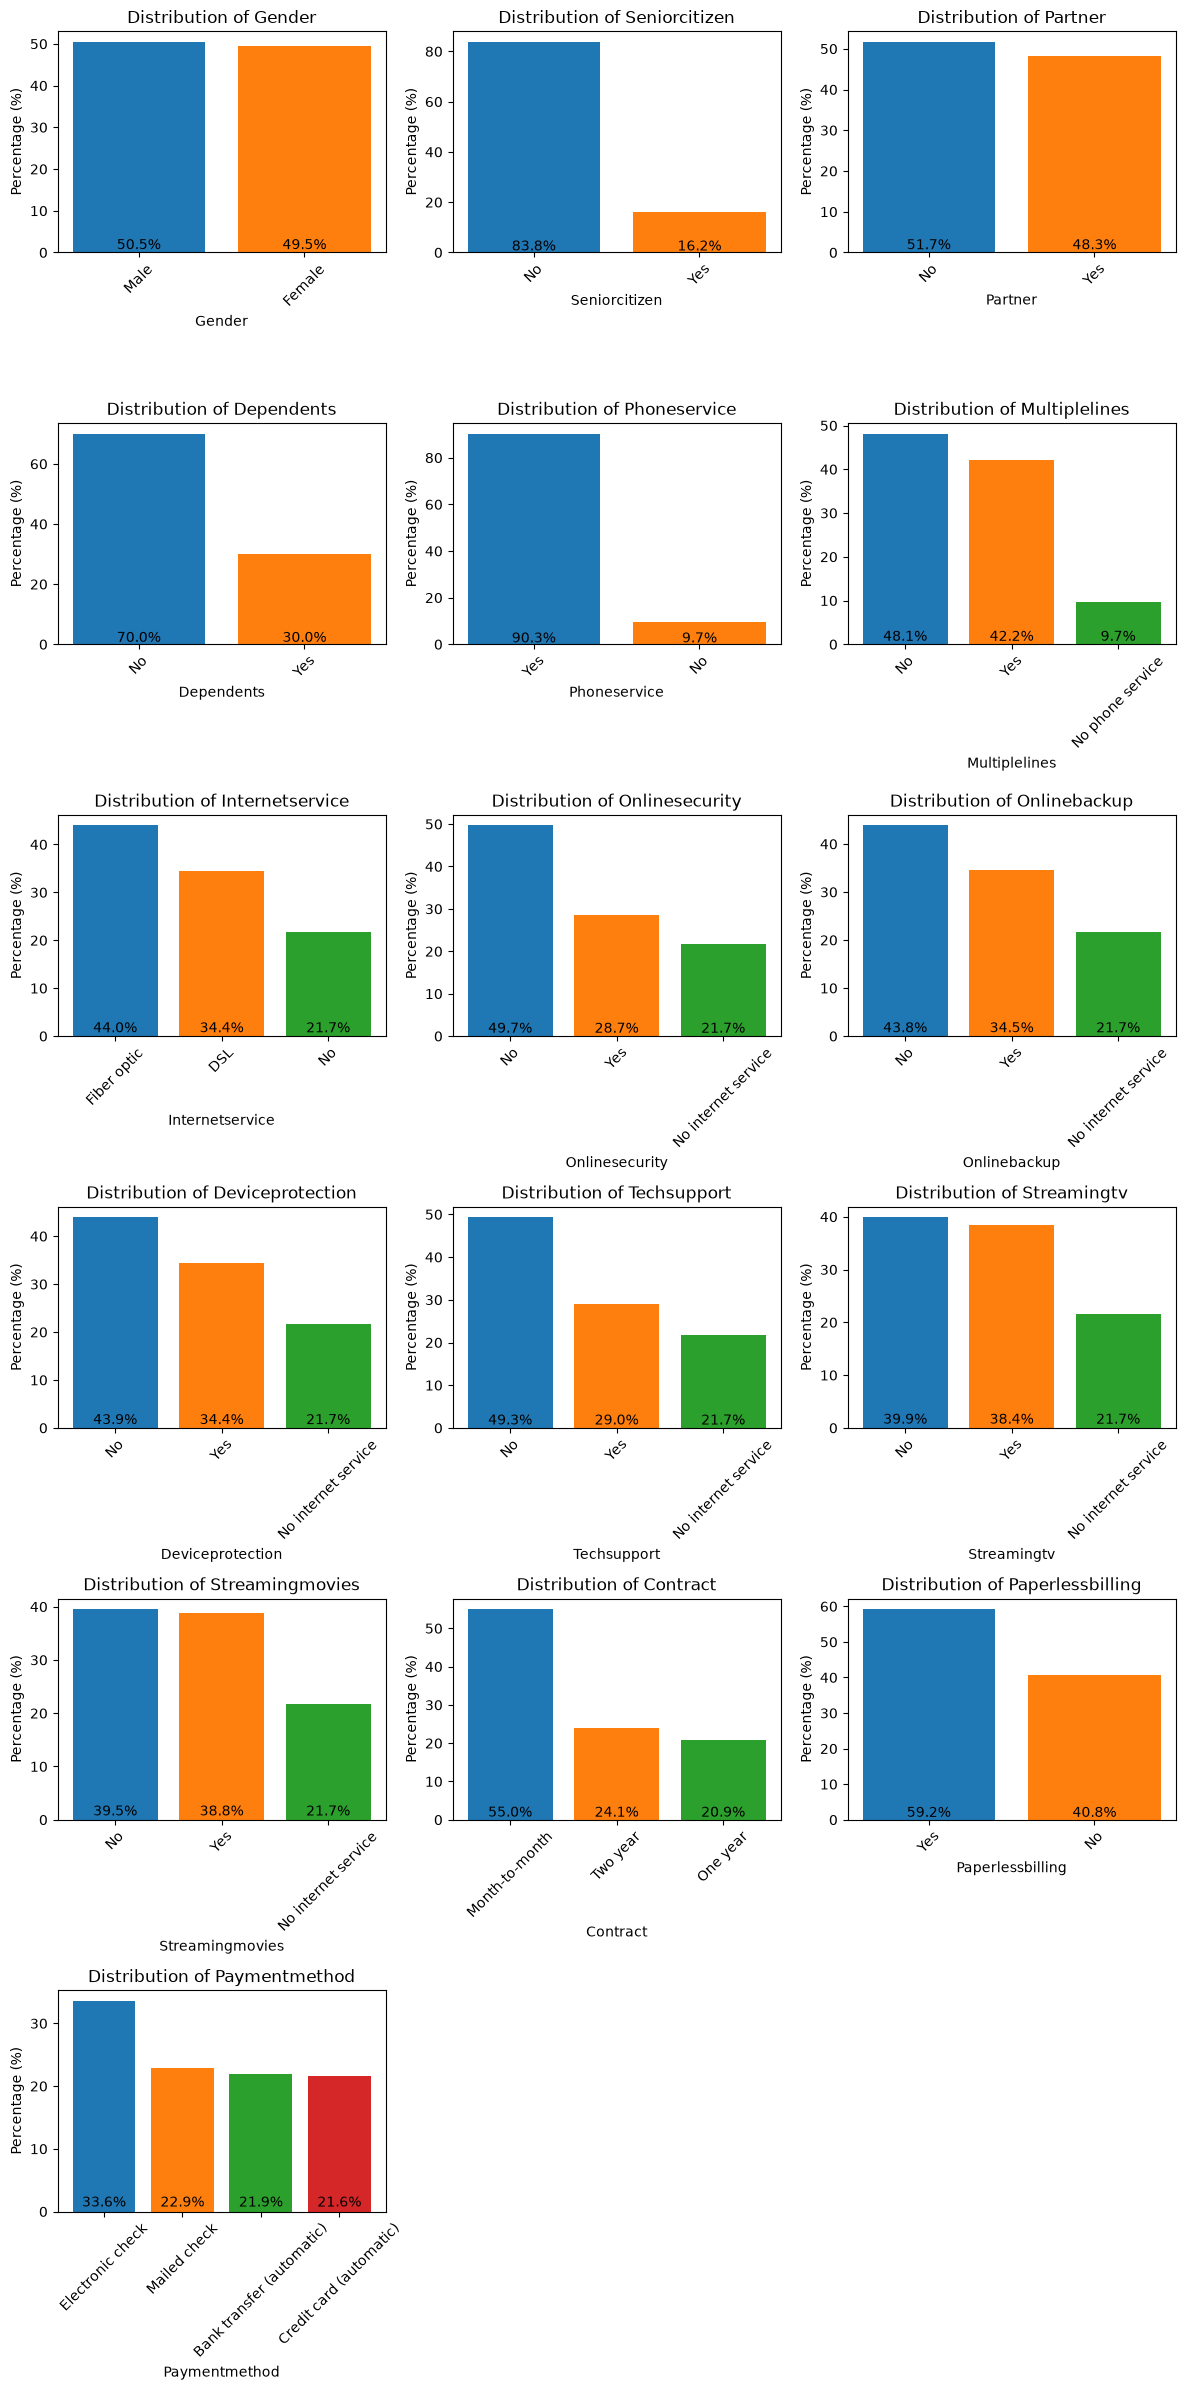

In [194]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
visualize_non_numerical_variable(df, cat_cols)

feature distributions, no churn here, just the composition of our base
- gender appprox. 50/50
- senior citizen: only 16.2% are seniors
- partner 48.3% yes, dependents only 30% yes
- phone service 90.3% -> almost everyone has it
- internet service: fiber 44.0%, DSL 34.4%, no internet 21.7%
- the 4 add-ons (security, backup, device protection, tech support) and both streaming services all show the SAME 21.7% "no internet service" slice as internet service itself
  - ACTION ITEM: check whether these add-ons are mechanically tied to internet service (correlate the block)
- contract: month-to-month dominates at 55.0%, two year 24.1%, one year 20.9%
- paperless billing 59.2% yes
- payment method: electronic check is the biggest single method at 33.6%, the other three sit around 22%

## EDA notes: categorical features vs churn

base churn rate approx. 26%, so anything near that = no signal, anything well above/below = something

gender: looks alike, nearly as many male / female clients churned (26.2% vs 26.9%) 
- cramers v with churn = 0.00 -> zero signal, can be dropped

seniors skew hard into both high-churn attributes at once:
  - month-to-month: seniors 70.7% vs non-seniors 52.0% (+18pts toward the worst contract type)
  - fiber optic: seniors 72.8% vs non-seniors 38.4% (nearly double, the 41.9%-churn product)
  - only 4.6% of seniors are in the safe no-internet bucket vs 25% of non-seniors
- my "longer contracts -> annoyed" guess was WRONG: seniors hold FEWER two-year contracts (12.7% vs 26.3%)
- conclusion: senior churn is a COMPOSITION EFFECT / proxy, not an age effect. seniors just sit disproportionately in the risky segments (m2m + fiber). matches the weak direct association of 0.15
- implication: SeniorCitizen will likely carry little independent signal once Contract + InternetService are in the model

partner: no partner churns more (33.0%) than with partner (19.7%) -> having a subscription with a partner seems to lead to a higher lock-in effect

dependents: same direction, no dependents 31.3% vs 15.5% -> underscores the partner intuition, when people are dependent on a subscription it is less likely to be cancelled
- note: partner <-> dependents are correlated (cramers v 0.45), so these two are partly the same story, not independent evidence

phone service: alike (26.7% vs 24.9%), churn association = 0.00 -> useless for churn

multiple lines: alike (~25-29%), association = 0.04
- IMPORTANT: phone service <-> multiple lines = 1.00 (somewhat redundant, multiple lines contains a "no phone service" category fully determined by phone service). we could keep one, drop the other

internet service: 41.9% of all fiber optic customers churned -> something seems off with that service. DSL 19.0%, no internet 7.4%
- this is the most actionable product finding. likely price or service-quality issue with fiber, could flag for the business

online security: no security 41.8% vs yes 14.6% vs no internet 7.4%. similar shape to internet service
online backup: no 39.9% vs yes 21.5% vs no internet 7.4%. similar to internet service
device protection: no 39.1% vs yes 22.5% vs no internet 7.4%. similar to internet service
tech support: no 41.6% vs yes 15.2% vs no internet 7.4%. similar to internet service

-> STRUCTURAL NOTE on the whole internet block:
   all of these (internet service + the 4 add-ons + streaming below) sit at 0.71-0.77 cramers v with EACH OTHER.
   reason: the add-ons are derived from internet service. no internet -> mechanically "no internet service" in all of them (that's the shared 7.4% / 21.7% bucket).
   so these are NOT 6 independent churn signals, they collapse into roughly ONE ("has internet, and what kind")

model note:
   - trees handle the redundancy fine
   - for logistic regression collapse the block; rely on regularization

streaming tv: no 33.5% vs yes 30.1% vs no internet 7.4%. pretty even between yes/no.
streaming movies: no 33.7% vs yes 29.9% vs no internet 7.4%. pretty even.
- streaming tv <-> streaming movies = 0.77 -> people with streaming tv also stream movies, confirmed. weakest churn signal of the internet block (0.23)

contract: month-to-month churns the most (42.7%) vs one year 11.3% vs two year 2.8% -> makes sense, the others are locked in
- STRONGEST single predictor: cramers v with churn = 0.41
- for 1/2 year contracts it would make sense to check when those started (renewal timing)

paperless billing: yes churns more (33.6%) than no (16.3%). association 0.19
- probably a proxy for younger / less committed / digital-only customers rather than a cause. weak but present

payment method: electronic check is the standout -> 45.3% churn, the single highest churn category in the whole dataset
- mailed check 19.1%, bank transfer (auto) 16.7%, credit card (auto) 15.2%
- automatic payment methods churn far less -> payment friction / commitment signal. association 0.30, third strongest

## predictor ranking (cramers v with churn)
contract 0.41 > online security 0.35 > tech support 0.34 > internet service 0.32 > payment method 0.30 > online backup 0.29 > device protection 0.28 > streaming 0.23 > paperless 0.19 > dependents/senior/partner ~0.15 > multiple lines 0.04 > phone service 0.00 > gender 0.00

## numericals missing
this matrix is categorical-only. tenure, monthly charges, total charges are NOT here.
- tenure is usually one of the strongest churn predictors in this kind of data -> check churn rate by tenure bucket.
- total charges ≈ monthly charge × tenure -> expect collinearity, watch for tenure=0 blanks.

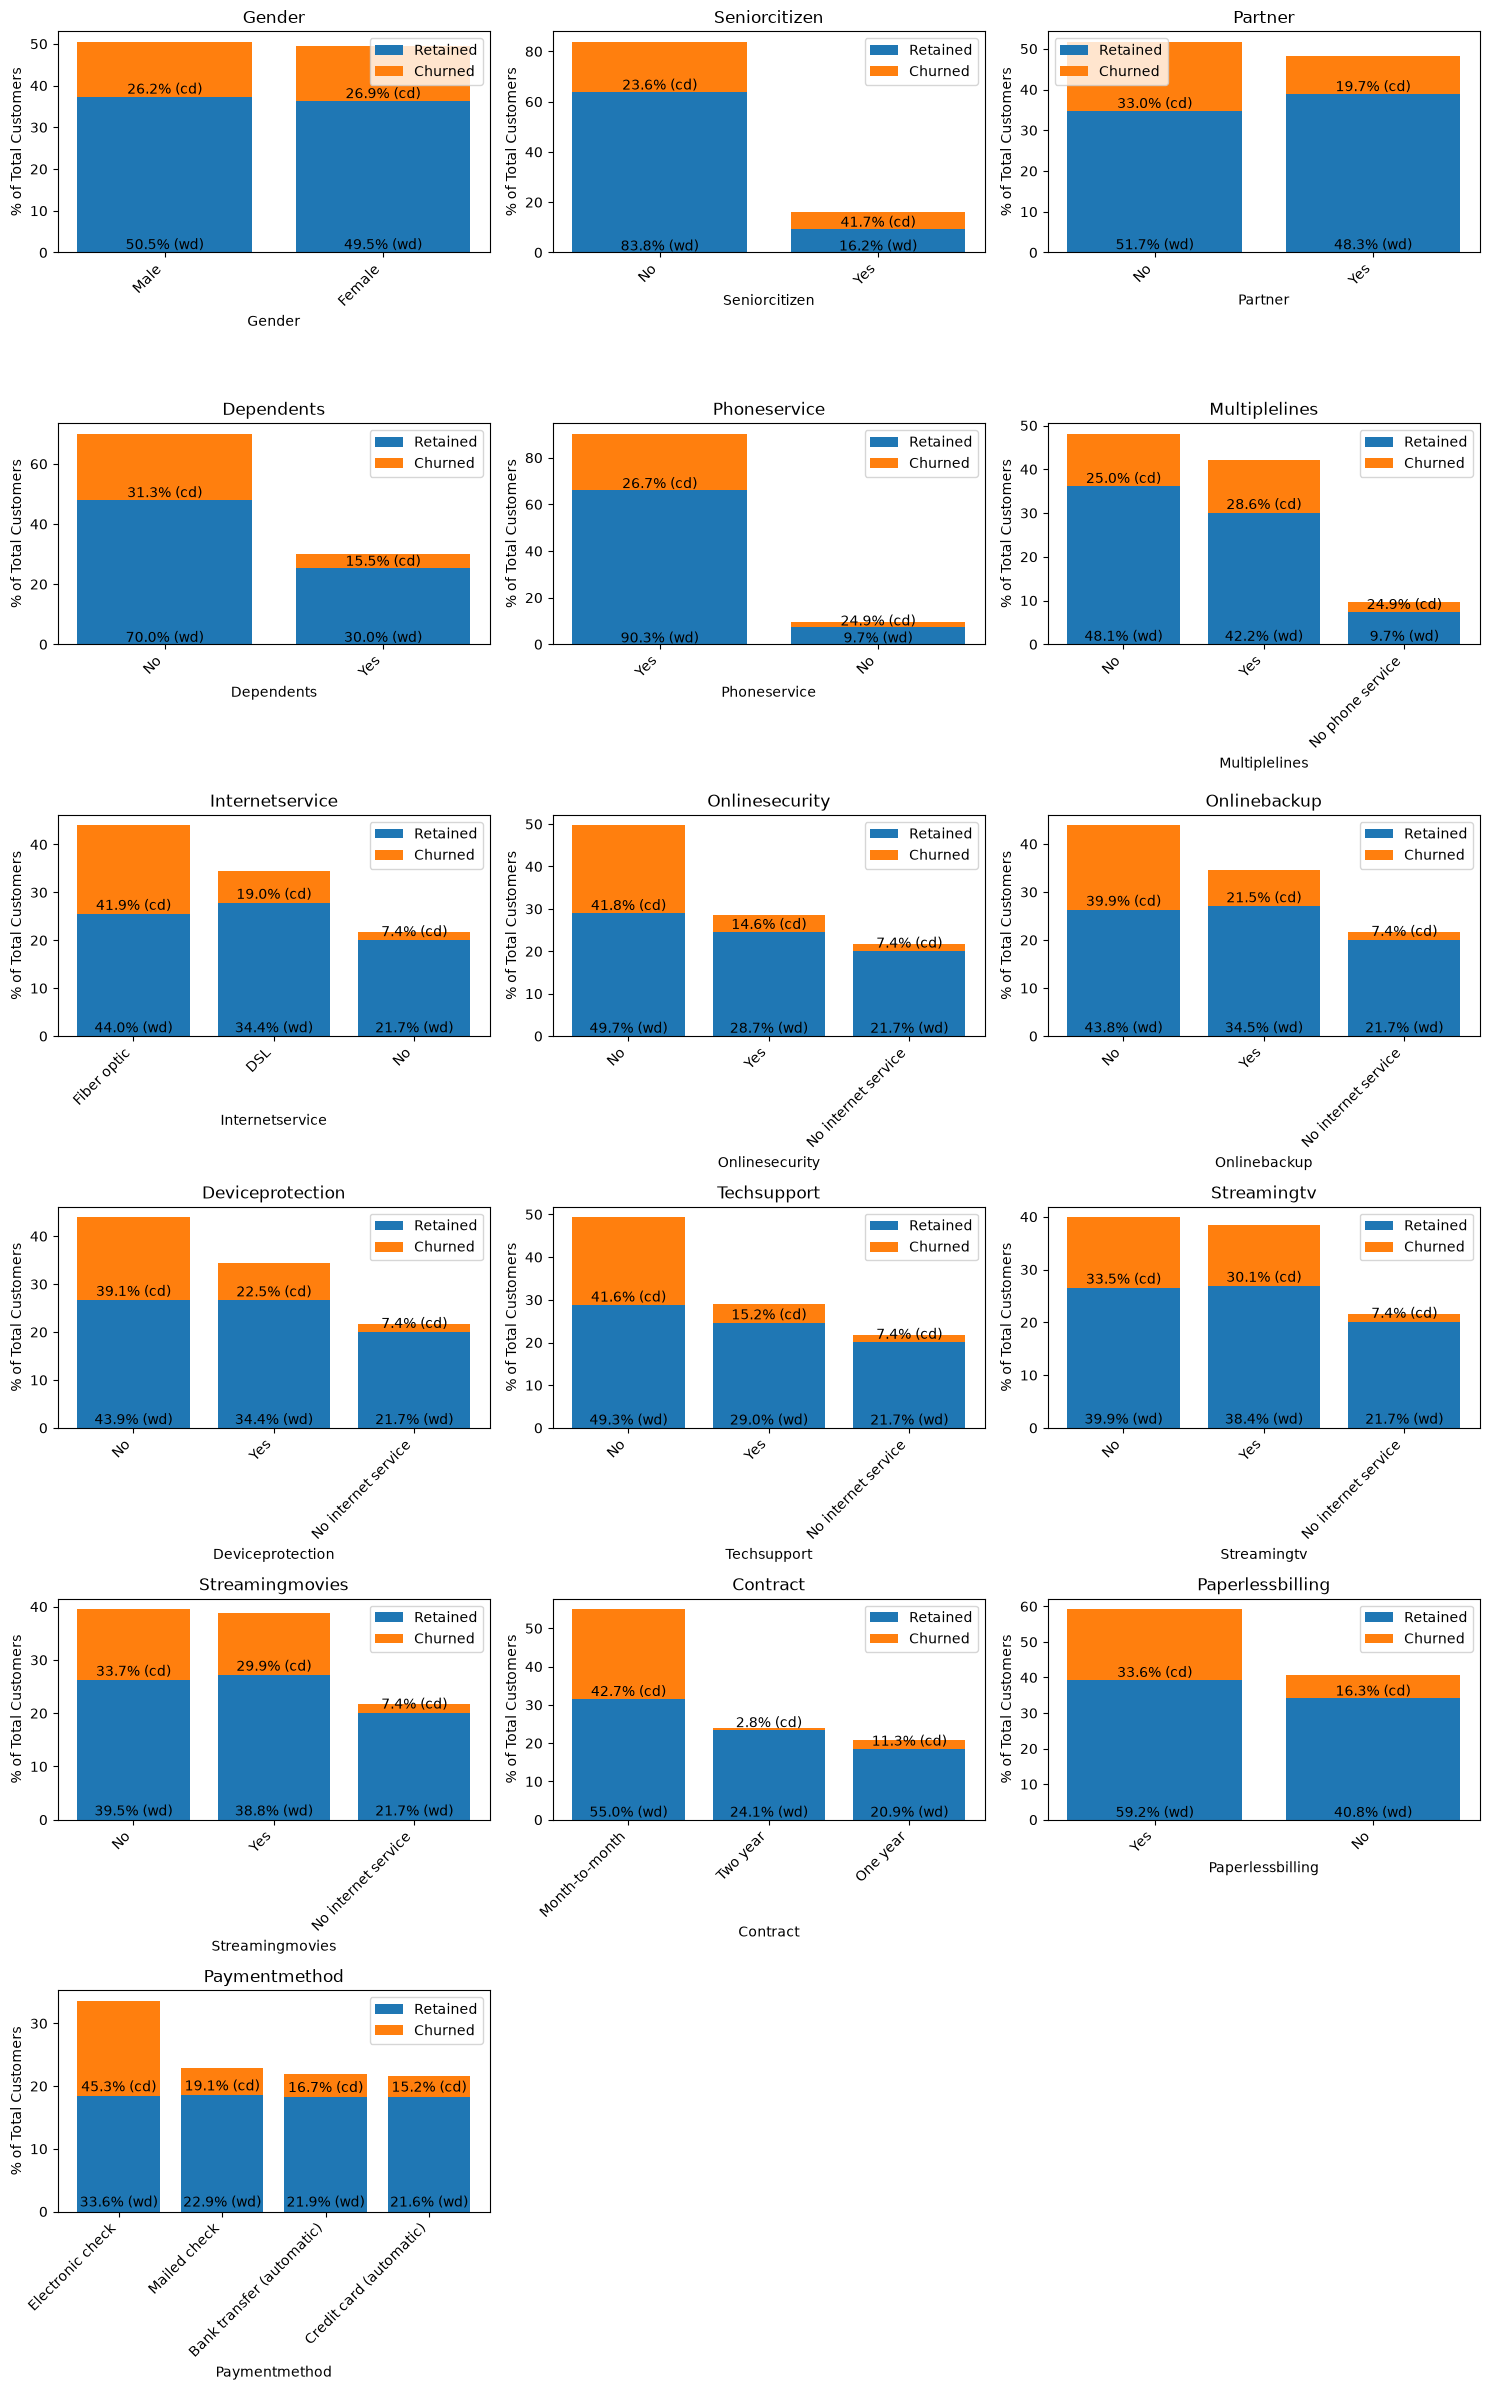

In [138]:

non_numerical_churn_distribution(df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'])

churn rate per category, base rate approx 26.5%, read each category against that
- gender: 26.2% (m) vs 26.9% (f) -> sits on the base rate, no signal
- senior citizen: 41.7% vs 23.6% -> seniors churn clearly more
  - ACTION ITEM: could be a composition effect (seniors on worse contracts (pay more) / products), verify with crosstabs + a stratified comparison
- partner: no partner 33.0% vs with partner 19.7% -> a partner looks protective (lock in effect)
- dependents: no dependents 31.3% vs with 15.5% -> same direction as partner
  - ACTION ITEM: partner and dependents may be the same underlying signal, check their correlation
- phone service: 26.7% vs 24.9% -> no signal
- multiple lines: approx. 25-29% across the board -> no real signal
- internet service: fiber 41.9% vs DSL 19.0% vs no internet 7.4% -> fiber is the standout problem
  - ACTION ITEM: price or service-quality issue with fiber? should be flagged for the business
- online security / backup / device protection / tech support: the "no" group churns approx 40%, the "yes" group far less, and all share the same 7.4% "no internet service" slice
  - ACTION ITEM: these look like the same shape as internet service, check whether they are one signal
- streaming tv / movies: fairly even between yes (approx. 30%) and no (approx. 33%), same 7.4% no-internet slice
- contract: month-to-month 42.7% vs one year 11.3% vs two year 2.8% -> by far the sharpest separation we have seen
- paperless billing: yes 33.6% vs no 16.3% -> paperless churns more
- payment method: electronic check 45.3%, the single highest-churn category in the dataset, the other three methods sit at 15-19%
  - ACTION ITEM: electronic check reads as payment friction / low commitment, check it against the auto-pay methods

In [ ]:
# ACTION ITEM 1: How are senior citizens and contract type related?
pd.crosstab(df.SeniorCitizen, df.Contract, normalize='index')

Contract,Month-to-month,One year,Two year
SeniorCitizen,,,
No,0.519912,0.217421,0.262667
Yes,0.706655,0.166375,0.126970


In [ ]:
pd.crosstab(df.SeniorCitizen, df.InternetService, normalize='index')

InternetService,DSL,Fiber optic,No
SeniorCitizen,,,
No,0.366379,0.383833,0.249788
Yes,0.226795,0.727671,0.045534


senior x contract and senior x internet (row-normalised), checking the senior composition hypothesis
- seniors are 70.7% month-to-month vs 52.0% non-seniors -> they skew into the worst contract type
- seniors are 72.8% fiber vs 38.4%, and only 4.6% of seniors have no internet vs 25% -> they skew into the worst product and almost none sit in the safe no-internet bucket
- seniors hold FEWER two-year contracts (12.7% vs 26.3%) -> the earlier "longer contract -> annoyed" guess is wrong
- this shows seniors are distributed into the high-churn segments, it does not yet prove there is no independent age effect
  - ACTION ITEM: compare senior vs non-senior churn WITHIN the same segment to separate composition from a real age effect

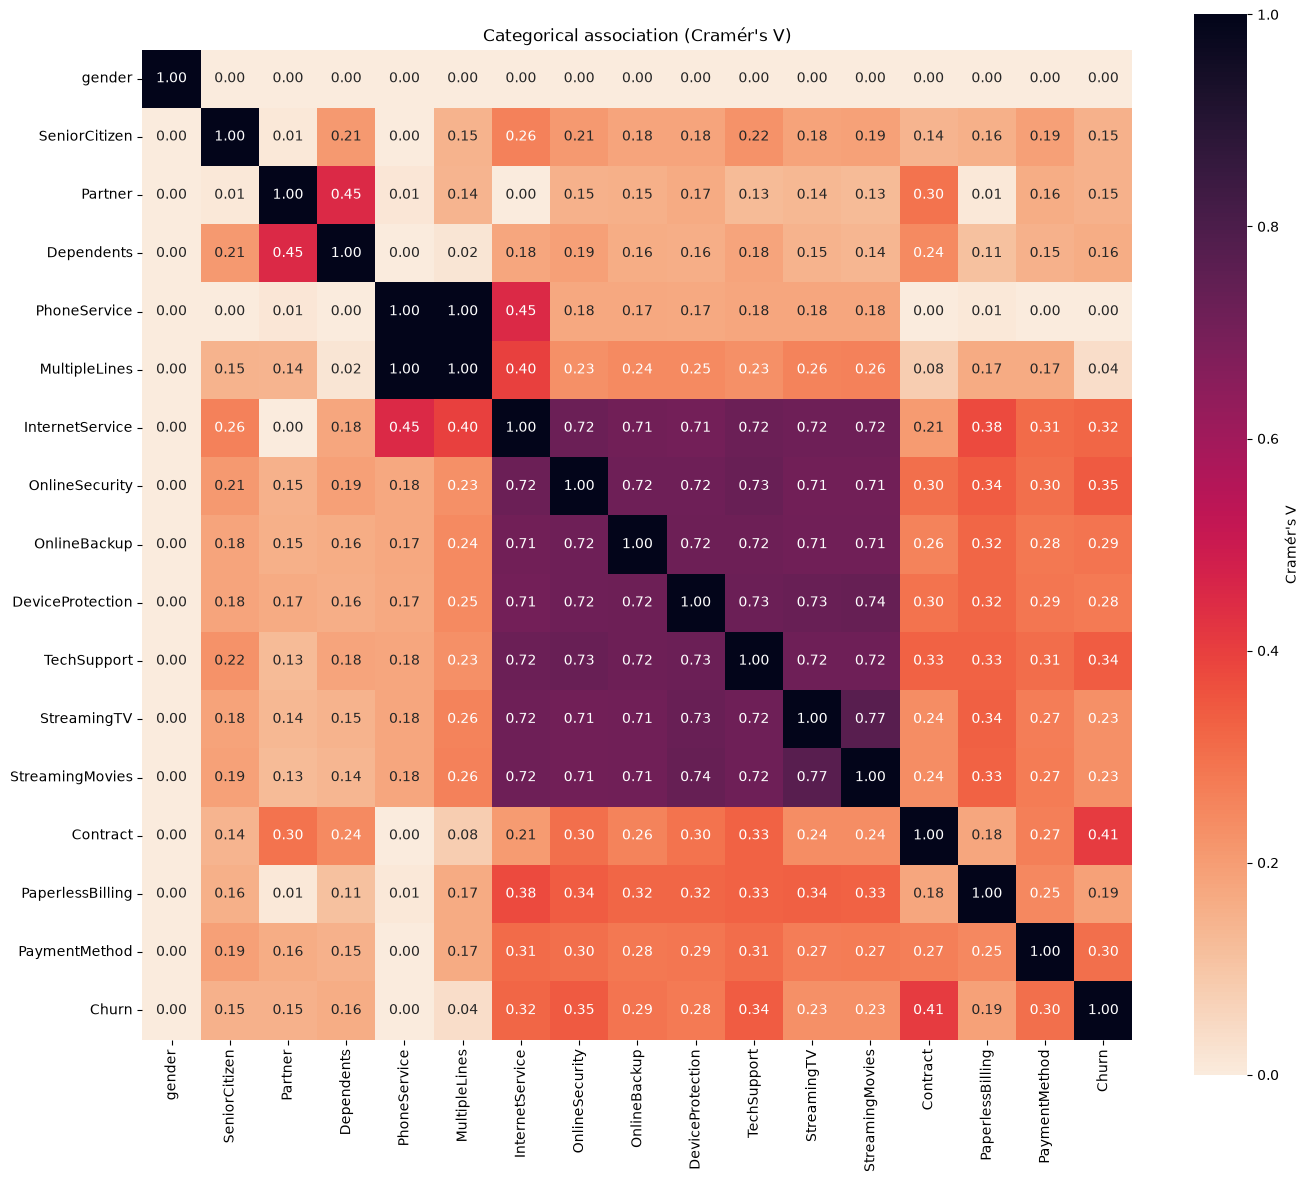

In [164]:
assoc = categorical_association_matrix(df, ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'])

plt.figure(figsize=(14, 12))
sns.heatmap(assoc, annot=True, fmt='.2f', cmap='rocket_r', square=True,
            cbar_kws={'label': "Cramér's V"})
plt.title("Categorical association (Cramér's V)")
plt.tight_layout()
plt.show()

categorical association (cramers v, 0 = independent, 1 = one determines the other, unsigned)
this resolves several of the ACTION ITEMs above
- gender: 0.00 with everything incl churn -> no signal confirmed, drop it
- internet service + the 4 add-ons + both streaming services all sit at 0.71-0.77 with EACH OTHER -> the add-ons are derived from internet service, they are NOT independent signals, they collapse into roughly one ("has internet, and what kind")
- phone service <-> multiple lines = 1.00 -> multiple lines fully contains phone service, one of them is redundant
- partner <-> dependents = 0.45 -> partly the same story, not independent evidence
- churn row: contract 0.41 strongest, then the internet block (online security 0.35, tech support 0.34, internet 0.32), payment method 0.30, down to phone service 0.00 and gender 0.00
- senior <-> churn only 0.15, but senior <-> internet 0.26 and senior <-> contract 0.14
  - ACTION ITEM: supports the composition hypothesis, still needs the crosstab + stratified check to confirm

## Numericals in the analysis
below we add the numerical attributes to the analysis

In [187]:
def numerical_churn_distribution(df, columns, target='Churn', bins=30, q=10):
    """"
        Binning the numerical values lets us compare it easier to the target distribution
    """
    fig, axes = plt.subplots(len(columns), 2, figsize=(13, 4 * len(columns)))
    base_churn = (df[target] == 'Yes').mean() * 100
    
    for (ax_l, ax_r), col in zip(axes, columns):

        # left view: histogram of numerical variable vs churn, using pdf to make it comparable with each other (i.e. we compare the shape not the bar height)
        for label, sub in df.groupby(target):
            ax_l.hist(sub[col].dropna(), bins=bins, density=True, alpha=0.5, label=label)
        ax_l.set_title(f'PDF {col} by churn'); ax_l.legend()

        # right view: absolute numbers, we create quantiles and compare them with each other 
        binned = pd.qcut(df[col], q=q, duplicates='drop')
        rate = df.groupby(binned, observed=True)[target].apply(lambda x: (x == 'Yes').mean() * 100)
        rate.plot(kind='bar', ax=ax_r)
        ax_r.axhline(base_churn, ls='--', color='gray')  # base-rate reference
        ax_r.set_title(f'Quantile churn rate by {col} bin'); ax_r.tick_params(axis='x', rotation=45)
    fig.tight_layout(); plt.show()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

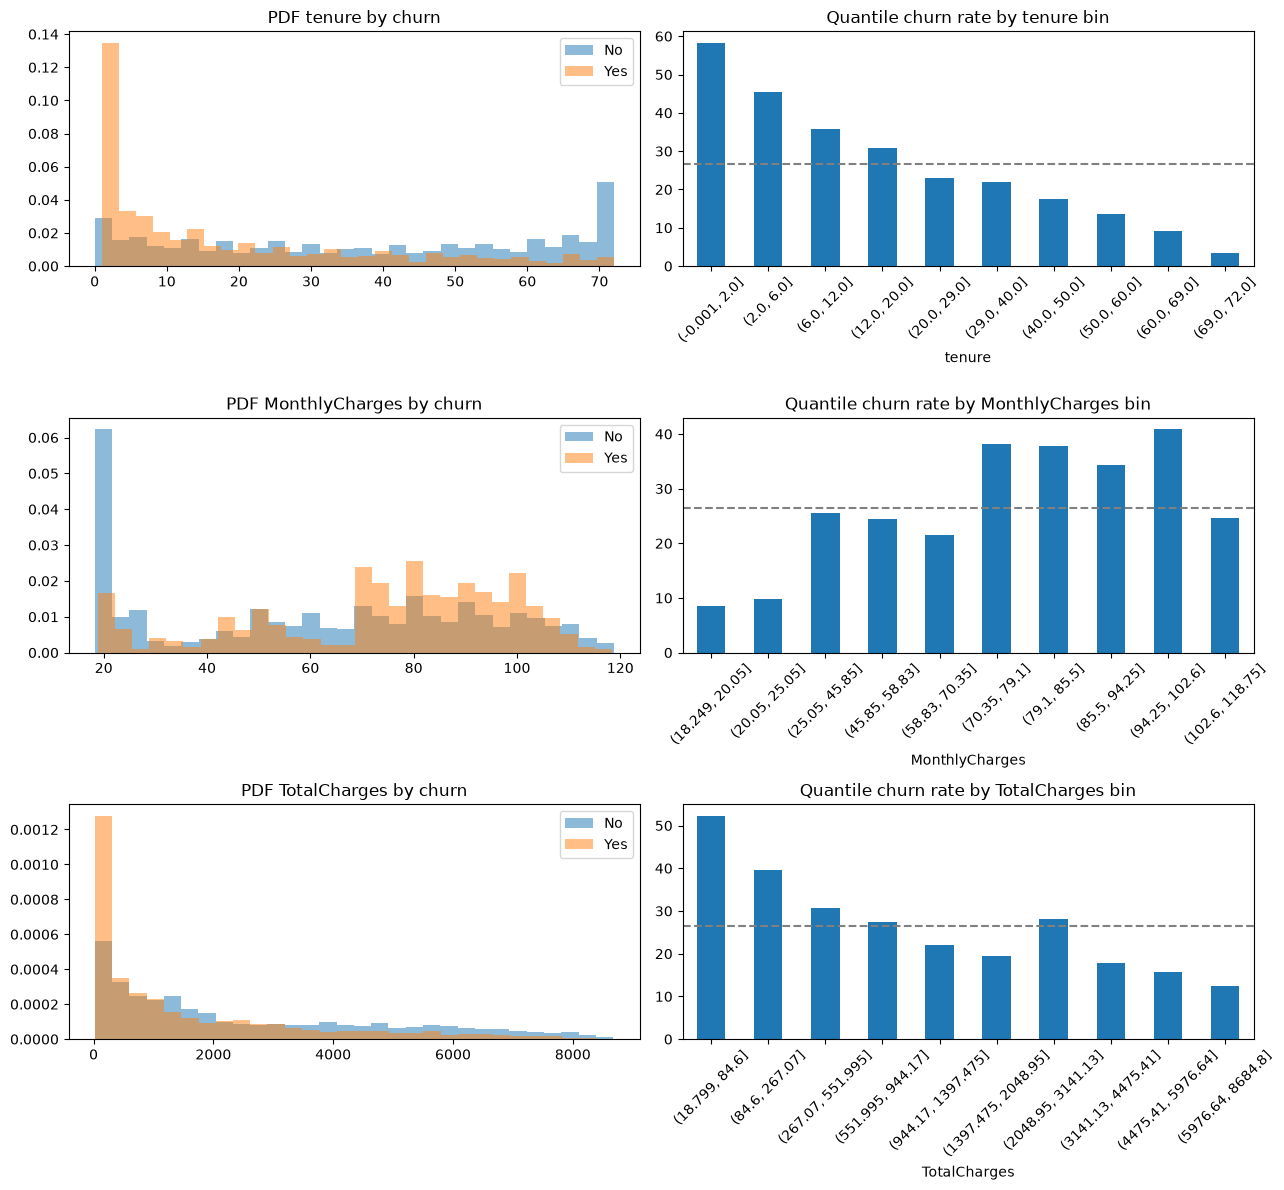

In [190]:
numerical_churn_distribution(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])

numerical features binned vs churn (left: density per churn class, right: churn rate per bin, dashed = base rate)

tenure:
- churners are concentrated in the first few months, approx 60% churn in the 0-2 bin, more than double the base rate
- churn rate falls monotonically and drops below base rate around the 20-29 bin -> the longer they stay, the less they leave
- a retained spike sits at the max roughly 70 months -> the loyal long-tenure base
  - ACTION ITEM: possible small bump around 12 months, check if those are 1-year contracts at renewal (crosstab tenure_bin x contract)

monthly charges:
- cheap (around 20) is very safe (roughly 9%), the 70-102 band is highest (34-41%), the very top bin (102-118) drops back to 24%-ish
  - ACTION ITEM: the high-charge churn may just be the fiber group, check monthly charges vs internet service
  - ACTION ITEM: the top-bin drop may be heavily-bundled / locked-in customers, speculative

total charges:
- same shape as tenure, high churn when spend is low (new customers), low churn as spend grows
- a local bump sits in the (2048, 3141] bin (approx. 28% vs approx. 19% neighbors)
  - ACTION ITEM: total charges may just be monthly x tenure re-expressed, check its correlation with tenure
  - ACTION ITEM: the 2k bump may be annual-contract customers, a guess

# Combine numerical analysis with categorical analysis

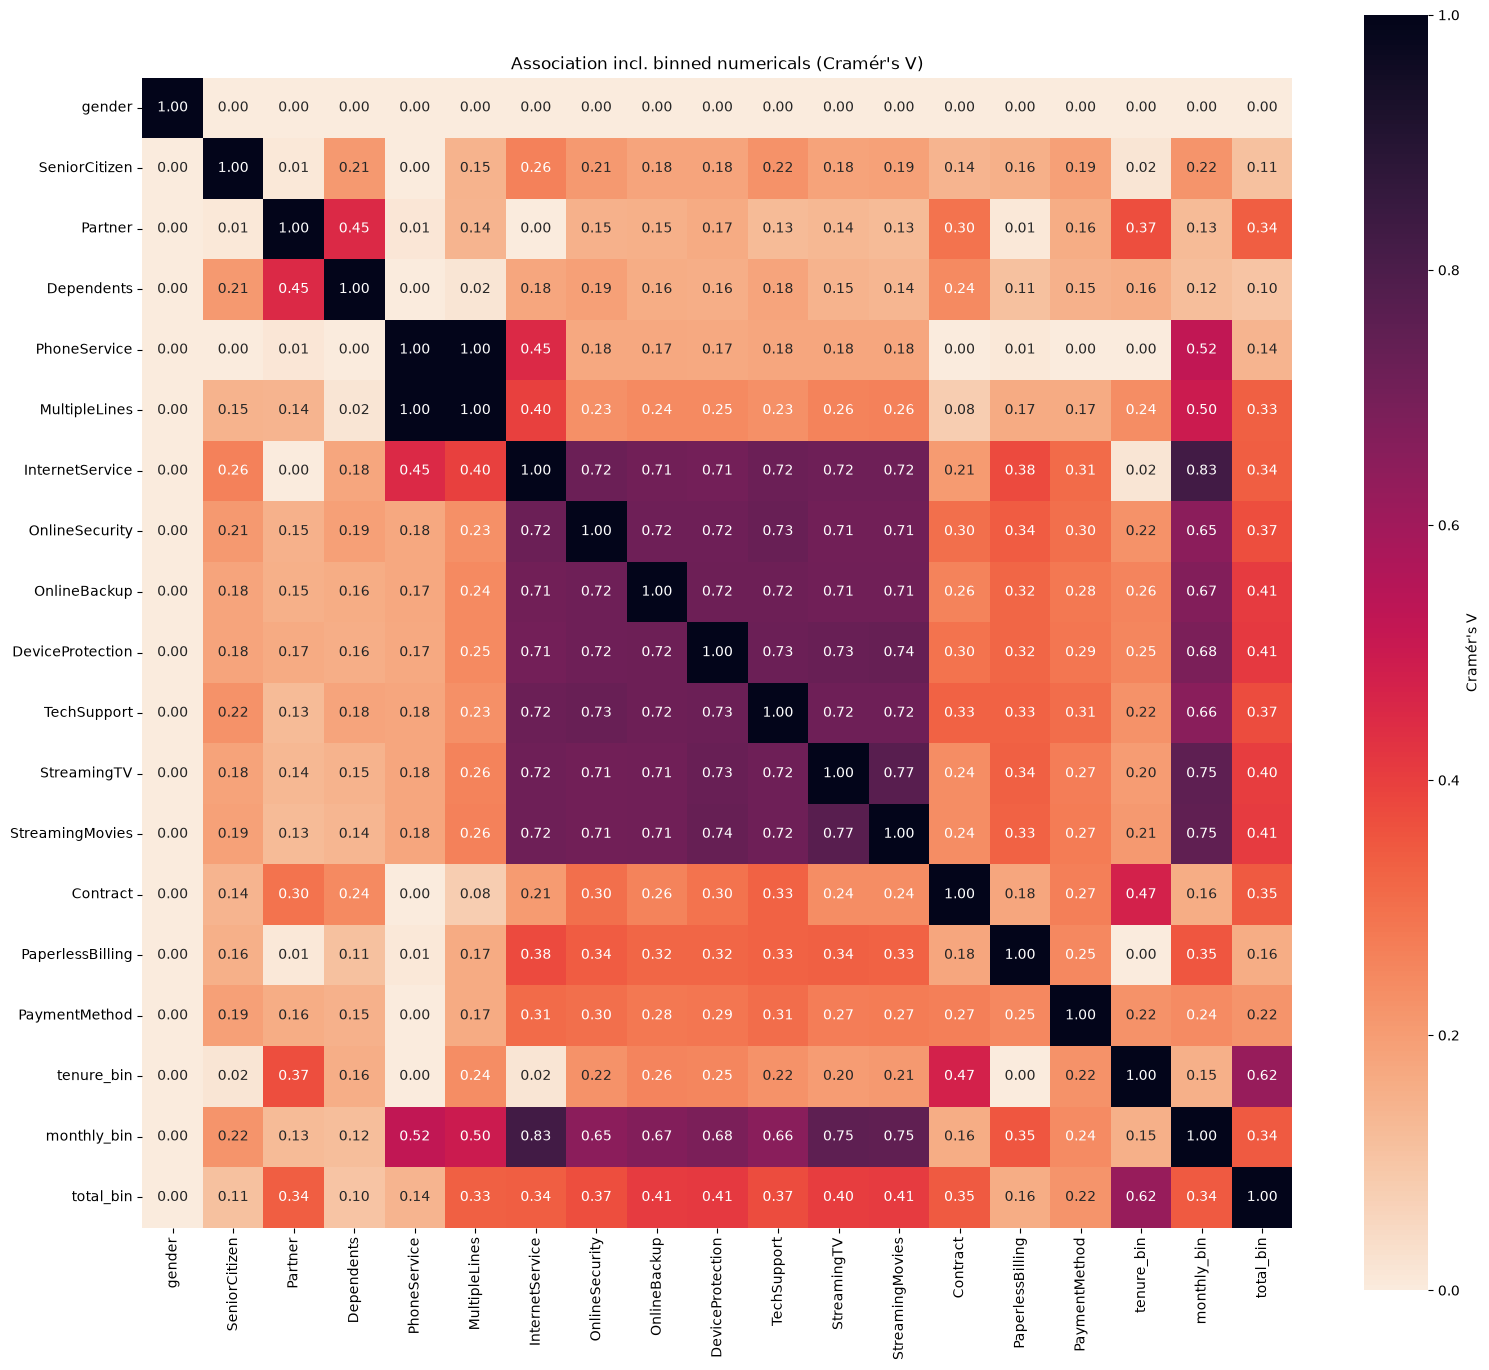

In [197]:
# bin the numericals so they can enter the categorical matrix
df['tenure_bin']  = pd.cut(df['tenure'], bins=[0, 3, 6, 12, 24, 48, 72], include_lowest=True)
df['monthly_bin'] = pd.qcut(df['MonthlyCharges'], q=5, duplicates='drop')
df['total_bin']   = pd.qcut(df['TotalCharges'],   q=5, duplicates='drop')

binned_num = ['tenure_bin', 'monthly_bin', 'total_bin']
assoc = categorical_association_matrix(df, cat_cols + binned_num)

plt.figure(figsize=(16, 14))
sns.heatmap(assoc, annot=True, fmt='.2f', cmap='rocket_r', square=True,
            cbar_kws={'label': "Cramér's V"})
plt.title("Association incl. binned numericals (Cramér's V)")
plt.tight_layout(); plt.show()

association incl. binned numericals (cramers v), resolves the numerical ACTION ITEMs
- monthly_bin <-> internet service = 0.83, the strongest off-diagonal in the matrix -> monthly charge is almost determined by internet type, this is the fiber story
- monthly_bin also 0.65-0.75 with the whole services block -> monthly charge is really a composite of how many services a customer buys, not an independent feature
- tenure_bin <-> contract = 0.47 -> tenure carries contract information
- total_bin <-> tenure_bin = 0.62 -> total charges is mostly tenure re-expressed

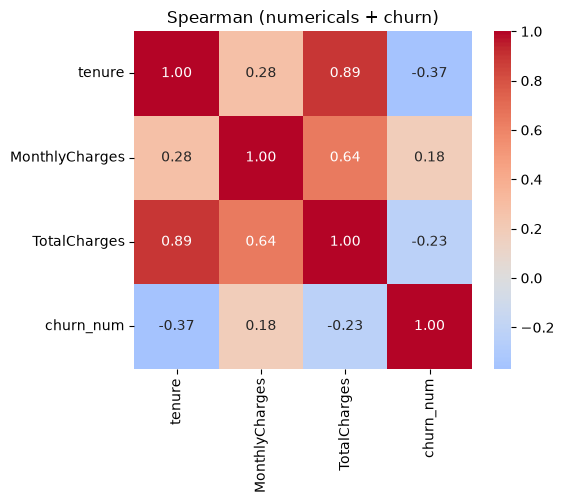

In [198]:
df['churn_num'] = (df['Churn'] == 'Yes').astype(int)
spearman = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'churn_num']].corr(method='spearman')

plt.figure(figsize=(6, 5))
sns.heatmap(spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title("Spearman (numericals + churn)"); plt.tight_layout(); plt.show()

spearman on raw numericals + churn (signed, monotonic trend)
- tenure <-> churn = -0.37 -> the dominant numerical signal, negative: more tenure, less churn - makes intuitively sense
- monthly charges <-> churn = +0.18 -> weak positive, consistent with the fiber effect rather than genuine price sensitivity
- total charges <-> churn = -0.23 -> negative, it follows tenure not monthly
- tenure <-> total charges = 0.89 -> the mechanical link (total = monthly x tenure)
- total charges inherits tenure's sign on churn even though monthly is positive, because it correlates far more with tenure (0.89) than monthly (0.64) -> total is tenure wearing clothing, shown numerically

In [200]:
# senior vs non-senior churn WITHIN month-to-month + fiber (where seniors concentrate)
stratum = df[(df['Contract'] == 'Month-to-month') & (df['InternetService'] == 'Fiber optic')]

stratum.groupby('SeniorCitizen').agg(
    churn_rate=('churn_num', 'mean'),
    n=('churn_num', 'size')
)

,churn_rate,n
SeniorCitizen,,
No,0.532172,1492
Yes,0.578616,636


In [201]:
df.pivot_table(index=['Contract', 'InternetService'],
               columns='SeniorCitizen', values='churn_num',
               aggfunc='mean')

SeniorCitizen                         No       Yes
Contract       InternetService                    
Month-to-month DSL              0.306391  0.427673
               Fiber optic      0.532172  0.578616
               No               0.183594  0.416667
One year       DSL              0.090385  0.120000
               Fiber optic      0.195181  0.185484
               No               0.025862  0.000000
Two year       DSL              0.013841  0.080000
               Fiber optic      0.081006  0.028169
               No               0.008143  0.000000

senior vs non-senior churn within month-to-month + fiber, and across all contract x internet cells
- within m2m + fiber: seniors 57.9% vs non-seniors 53.2% on a healthy senior n of 636 -> a 4.6pt gap, vs the 18pt raw gap (41.7 vs 23.6)
- conditioning on the single worst segment removes ~3/4 of the gap -> the senior effect is mostly composition
- across the full pivot the small residual shows up only in month-to-month (DSL +12pt, fiber +4.6pt) and disappears or reverses once customers are on 1/2-year contracts
- the big swings in the no-internet and two-year senior cells sit on tiny n and are noise
- conclusion: senior churn is mostly composition, with a small residual confined to month-to-month, it is not an independent lever

# EDA - consolidated findings

base churn rate approx. 26.5%, single Q1-Q2 snapshot, one row per customer (verified unique), no duplicates
total charges had blanks for tenure=0 customers (not billed yet) -> coerced to numeric, set to 0

## what drives churn (resolved)
1. contract type, the strongest single driver: month-to-month 42.7% vs one year 11.3% vs two year 2.8% (cramers v 0.41), locked-in customers barely churn
2. tenure, the strongest and genuinely independent numerical driver: approx. 60% churn in the first 2 months, monotonic decline, below base rate after around 20-29 months (spearman -0.37), the early-tenure cliff is the clearest pattern we have
3. fiber optic, a product problem: 41.9% vs DSL 19.0% vs no internet 7.4%, the biggest actionable product finding, likely price or quality
4. payment method, electronic check the standout: 45.3% vs roughly 15-17% for the auto-pay methods (cramers v 0.30), reads as low commitment
5. paperless billing yes churns more (33.6% vs 16.3%) but weak (0.19), likely a proxy for less-committed / digital customers (switching faster)
6. partner and dependents are protective (no-partner 33.0% vs 19.7%, no-dependents 31.3% vs 15.5%) but correlated (0.45) -> one shared household-stability signal, not two

## what is NOT an independent signal (redundancy structure)
- gender: 0.00 with churn -> drop
- phone service and multiple lines: 1.00 association, multiple lines contains phone service -> keep one
- the internet add-ons (security, backup, device protection, tech support, streaming tv/movies): 0.71-0.77 with each other and internet service -> collapse into one "has internet, and what kind" signal, not 6 drivers
- monthly charges: 0.83 with internet service, 0.65-0.75 with the services block, only +0.18 spearman with churn -> a composite of how many services a customer buys, the fiber story on a continuous axis
- total charges: 0.89 with tenure, -0.23 with churn following tenure -> mostly tenure re-expressed
- senior citizen: the 41.7% churn is around 3/4 composition (70.7% m2m, 72.8% fiber), gap collapses to 4.6pt within m2m+fiber -> not an independent lever

## the at-risk customer (profile)
month-to-month, low tenure (first months), fiber optic, electronic check, paperless billing, no partner or dependents

## implications for modelling
- drop gender, drop one of phone service / multiple lines
- the internet/services block + monthly charges are heavily collinear -> trees handle it, for logistic regression collapse the block or lean on regularisation
- genuinely independent signals: contract, tenure, internet service (fiber), payment method, household (partner/dependents)
- total charges is redundant with tenure, its non-redundant part is the charge_delta feature (current vs historical avg monthly) -> save for feature engineering

# Dataset creation

In [214]:
class ChurnDataset:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)

        # since we already know the dataset we can start with the clean up in the dataset initialization
        # remove columns that are misleading / irrelevant for the analysis (i.e. customer satisfaction)
        self.df = self.df.drop(columns=['customerID', 'gender', 'CustomerSatisfactionScore'])

        # convert total charges to numeric, coercing errors to NaN, fill the na values with 0, since all values are just of tenure 0 not paid yet
        self.df['TotalCharges'] = pd.to_numeric(self.df['TotalCharges'], errors='coerce').fillna(0)
        
        # engineered feature: is the customer currently paying less than their lifetime average?
        # lifetime average monthly = TotalCharges / tenure, compared to the current MonthlyCharges
        # 1 = current rate is below the historical average -> they pay less today than they used to (discount or downgrade)
        # adjusted the threshold to -2.0 to account for possible rounding errors
        implied_avg = self.df['TotalCharges'] / self.df['tenure'].replace(0, np.nan)
        self.df['ReceivedDiscount'] = np.where(self.df['MonthlyCharges'] - implied_avg < -2.0, 1, 0)
        self.df.loc[self.df['tenure'].eq(0), 'ReceivedDiscount'] = 0   # no history -> no discount

        # encode the target variable as categorical variables
        self.X = self.df.drop(columns=['Churn'])
        self.y = (self.df['Churn'] == 'Yes').astype(int)


    def get_split(self, test_size=0.2, random_state=42):
        # stratify on the target so the ~26% churn rate is preserved in both splits
        return train_test_split(self.X, self.y, test_size=test_size,
                                stratify=self.y, random_state=random_state)
        

In [220]:
data = ChurnDataset('Telco-Customer-Churn.csv')
X_train, X_test, y_train, y_test = data.get_split()

num_cols = X_train.select_dtypes(include='number').columns.tolist() # tenure, charges, senior citizens, discounts
cat_cols = X_train.select_dtypes(include='str').columns.tolist() # all other strings that we have

In [234]:
# use -1 for values we dont know yet
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,)

X_train_enc, X_test_enc = X_train.copy(), X_test.copy()
X_train_enc[cat_cols] = enc.fit_transform(X_train[cat_cols]) 
X_test_enc[cat_cols]  = enc.transform(X_test[cat_cols]) 

# 
model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                      subsample=0.9, colsample_bytree=0.9,
                      eval_metric='logloss', random_state=42)
model.fit(X_train_enc, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [235]:
proba = model.predict_proba(X_test_enc)[:, 1]   # predicted churn probability per test customer

print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC : {average_precision_score(y_test, proba):.3f}")   # the honest one under imbalance

def topk_metrics(y_true, scores, k_frac):
    y_true = np.asarray(y_true)                  # drop the pandas index so positional indexing lines up
    k = int(np.ceil(k_frac * len(scores)))
    top_idx = np.argsort(scores)[::-1][:k]       # the k highest-scored customers
    hits = y_true[top_idx].sum()                 # actual churners caught in that top-k
    precision = hits / k
    recall = hits / y_true.sum()
    lift = precision / y_true.mean()             # vs. picking at random
    return precision, recall, lift

print(f"\nbase churn rate (test): {y_test.mean():.3f}\n")
for frac in [0.10, 0.20, 0.30]:
    p, r, l = topk_metrics(y_test, proba, frac)
    print(f"top {int(frac*100):>2d}% -> precision@k {p:.3f}  recall@k {r:.3f}  lift {l:.2f}x")

ROC-AUC: 0.843
PR-AUC : 0.660

base churn rate (test): 0.265

top 10% -> precision@k 0.766  recall@k 0.289  lift 2.89x
top 20% -> precision@k 0.681  recall@k 0.513  lift 2.57x
top 30% -> precision@k 0.584  recall@k 0.660  lift 2.20x


the model's top-decile list finds churners nearly 3× better than random selection. -> k is a business decision, how much money we want to spend giving offers to custoemrs who would not churn

baseline for the model is set. we have a classic tree model. 

## precision vs recall (for the campaign list)
there are real churners out there, and we pick a list of customers to send retention offers to

precision = of the people WE picked, how many actually churn
- "is our list clean / are we spending the budget on the right clients"
- low precision -> we waste offers on people who were never going to leave

recall = of ALL the churners that exist, how many did we catch in our list
- "how many of the leavers did we actually flag"
- low recall -> lots of churners slip through and never get an offer

note the two denominators: precision is over OUR list, recall is over ALL churners
the tension: a short list is clean but misses most leavers (high precision, low recall), a long list catches more leavers but wastes more offers (low precision, high recall)


## reading the top-k results (base churn rate ~26.5%)

top 10%: precision 76.6%, recall 28.9%, lift 2.89x
- if we send offers to the riskiest 10% of customers, 77% of that list really churns -> only 23% wasted offers, a very clean list
- but we only catch 29% of all the churners -> the other 71% of leavers are not on this list and slip through
- the list is 2.89x richer in churners than if we had picked 10% of customers at random

top 20%: precision 68.1%, recall 51.3%, lift 2.57x
- wider net -> we now catch about half of all churners, two-thirds of the list is still real

top 30%: precision 58.4%, recall 66.0%, lift 2.20x
- catch two-thirds of all churners, but now ~42% of the list are false alarms who would have stayed

pattern: widen the list -> recall goes up (catch more leavers), precision goes down (waste more offers)
which size we pick is a BUSINESS call, not a model call -> it depends on the offer cost vs the value of saving a customer

## how the model is used in practice
the model does not output a yes/no churn decision, it outputs a churn PROBABILITY per customer -> we rank all active customers by that probability
campaign managers have a fixed retention budget, so they take the TOP-K riskiest customers off that ranked list and put them in the campaign
- this is a ranking / prioritisation tool, not a 0.5 classifier -> the cut-off k is a business decision (budget vs value of a saved customer), not a fixed threshold
- it is scored in BATCH (e.g. monthly, aligned to the campaign cycle), not in real time -> the features are slow-moving (contract, tenure, services), a live per-customer api would be over-engineering
- output = a scored selection list the campaign team pulls from, ordered by risk

np.float64(2279.7343035638223)

optimal campaign size: top 31.2%  (439 customers), expected profit 32,900


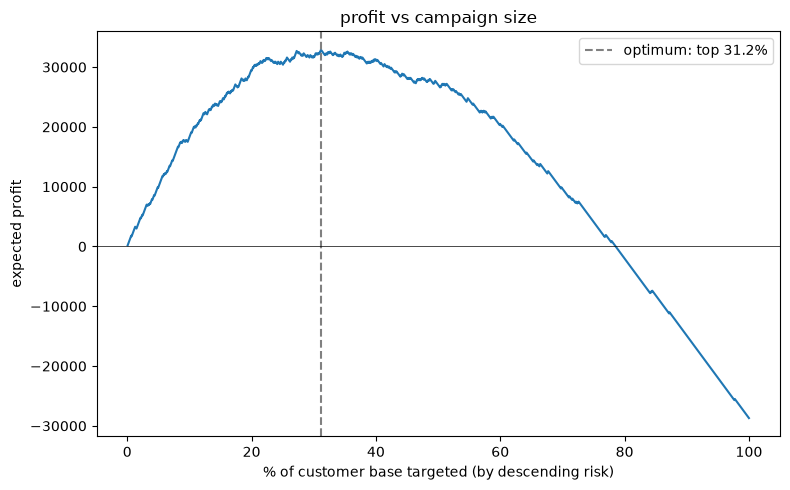

In [ ]:
# assumptions (placeholders, swap in real numbers from finance/marketing) 
clv        = 1000   # value of retaining one customer who would have churned
offer_cost = 100    # cost of one retention offer
save_rate  = 0.3    # fraction of targeted would-be churners the offer actually saves - we need AB testing for this

y_true = np.asarray(y_test)
order  = np.argsort(proba)[::-1]            # customers sorted by churn risk, highest first
tp     = np.cumsum(y_true[order])           # cumulative real churners caught in the top-k
k      = np.arange(1, len(y_true) + 1)
frac   = k / len(y_true)

profit = tp * save_rate * clv - k * offer_cost
best   = np.argmax(profit)
print(f"optimal campaign size: top {frac[best]*100:.1f}%  ({k[best]} customers), expected profit {profit[best]:,.0f}")

plt.figure(figsize=(8, 5))
plt.plot(frac * 100, profit)
plt.axvline(frac[best] * 100, ls='--', color='gray', label=f'optimum: top {frac[best]*100:.1f}%')
plt.axhline(0, color='black', lw=0.5)
plt.xlabel('% of customer base targeted (by descending risk)')
plt.ylabel('expected profit'); plt.title('profit vs campaign size')
plt.legend(); plt.tight_layout(); plt.show()

# SHAP analysis
To see which feature was how important for the task to rank the customers

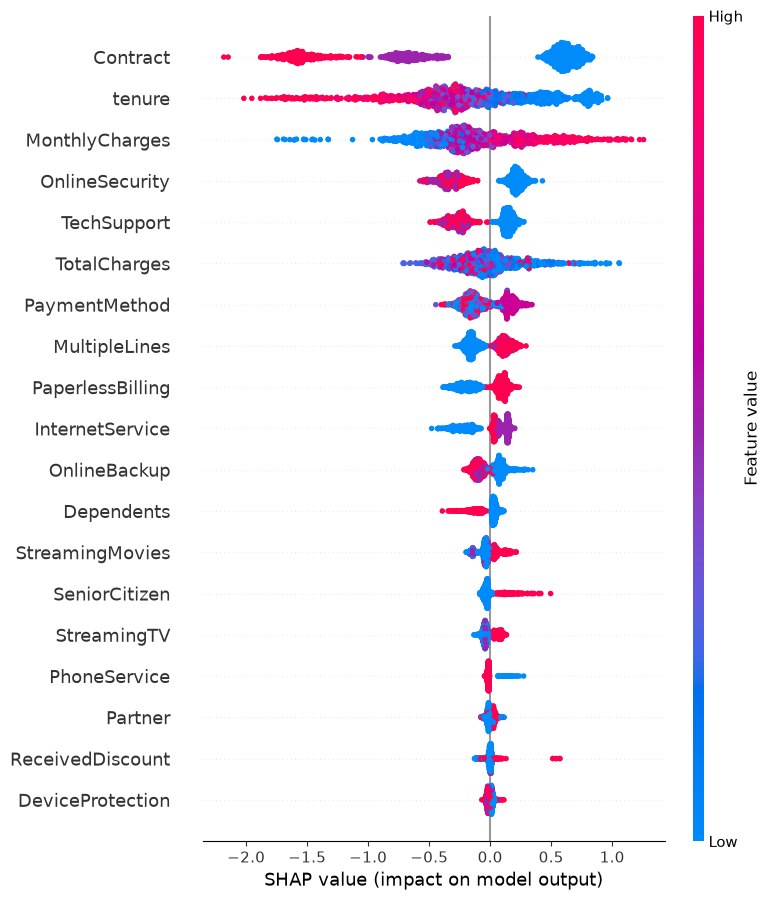

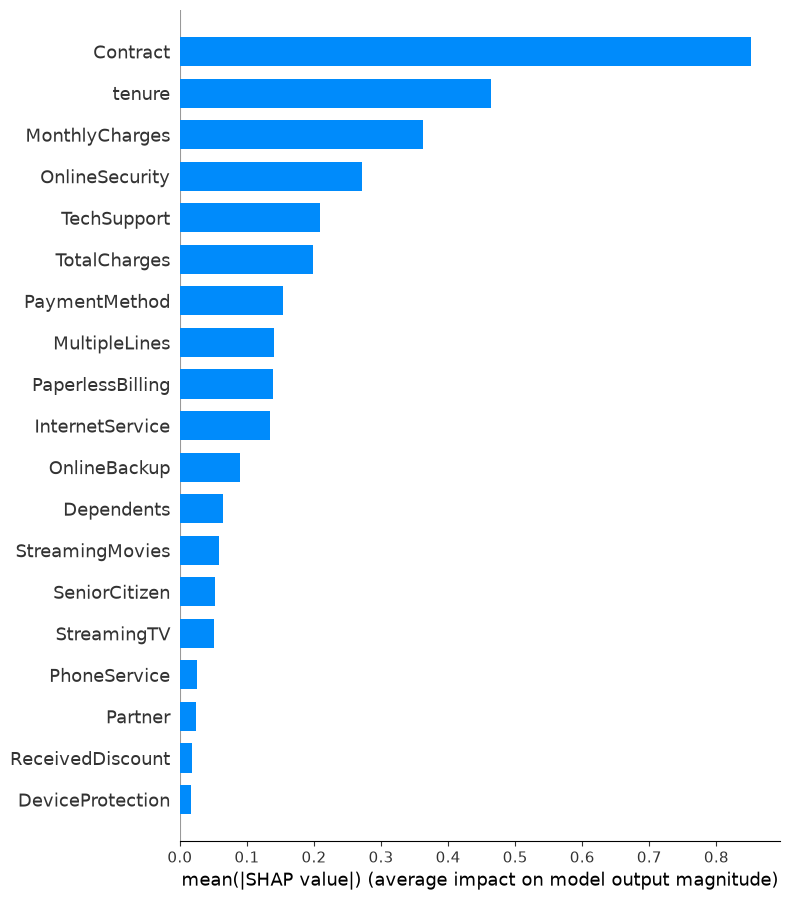

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_enc)

shap.summary_plot(shap_values, X_test_enc)                    # beeswarm: importance + direction
shap.summary_plot(shap_values, X_test_enc, plot_type='bar')   # clean global importance ranking